##QHO Density Matrix / Matrix Squaring
- using hbar=m=omega=1, then H = -1/2 d**2/dx**2 + 1/2x**2
- we want to built high temp density matrix, square it up to 5.12, compare quantum v. classical diagonals and extract ground state.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp
import matplotlib.style as style

style.use('dark_background')
plt.rcParams['text.usetex'] = False

#main constants, prof simplification hbar=m=omega=1
beta0 = 0.01
L = 6.0

dx = 0.05
x = np.arange(-L, L + dx, dx)
N = len(x)

print('N =', N)
print('dx =', dx)
print('beta0 =', beta0)
print('x range =', (x.min(), x.max()))

N = 241
dx = 0.05
beta0 = 0.01
x range = (np.float64(-6.0), np.float64(5.999999999999957))


### Problem 1: high temperature density matrix
- at tiny beta, split ke and pe approx with trotter-suzuki
- exp(-(x-x')2/(2beta) - (beta/4)(x2 + x'**2))
for beta = 0.01 it is about roh(x,x';0.91) ~ 3.989 exp(-50(x-x')^2-0.0025(x^2+x'^2))

In [34]:
#symbolic check of the numbers in the exponent/prefactor
beta = sp.Symbol('beta', positive=True)
xi, xj = sp.symbols('x_i x_j', real=True)

rho_sym = (1/sp.sqrt(2*sp.pi*beta)) * sp.exp(-(xi-xj)**2/(2*beta)) * sp.exp(-beta*(xi**2+xj**2)/4)

print('rho kernel:')
display(rho_sym)

rho_beta001 = rho_sym.subs(beta, sp.Rational(1,100))
print('beta = 0.01 form:')
display(rho_beta001)

print('prefactor numeric =', float(1/sp.sqrt(2*sp.pi*sp.Rational(1,100))))

rho kernel:


sqrt(2)*exp(-(x_i - x_j)**2/(2*beta))*exp(-beta*(x_i**2 + x_j**2)/4)/(2*sqrt(pi)*sqrt(beta))

beta = 0.01 form:


5*sqrt(2)*exp(-50*(x_i - x_j)**2)*exp(-x_i**2/400 - x_j**2/400)/sqrt(pi)

prefactor numeric = 3.989422804014327


### part 2: numerical grid expression

- build the NxN matrix Pij = roh(xi,xj;beta)
- python trick is broadcasting [this part tripped me up], thayne currie has a good course on git:
  - https://github.com/Aweymouth13/phys7943/blob/main/ScientificPythonNotes/NumPy/Python_NumPy_part5.md
  - https://github.com/Aweymouth13/phys7943/blob/main/ScientificPythonNotes/NumPy/Python_NumPy_part3.md
- make Xi and Xj 2d arrays so every pair (xi,xj) gets calculated at once

In [35]:
def rho_high_temp_matrix(x, beta):
    #turn the 1D x-grid into row/column objects so numpy broadcasts
    Xi = x[:, None]
    Xj = x[None, :]

    prefactor = 1 / np.sqrt(2*np.pi*beta)
    kinetic_piece = np.exp(-(Xi - Xj)**2 / (2*beta))
    potential_piece = np.exp(-beta*(Xi**2 + Xj**2) / 4)

    return prefactor * kinetic_piece * potential_piece

P0 = rho_high_temp_matrix(x, beta0)

print('matrix shape =', P0.shape)
print('P[center, center] =', P0[N//2, N//2])
print('trace integral approx Z(beta0) =', np.trace(P0) * dx)

matrix shape = (241, 241)
P[center, center] = 3.989422804014327
trace integral approx Z(beta0) = 45.31590544518885


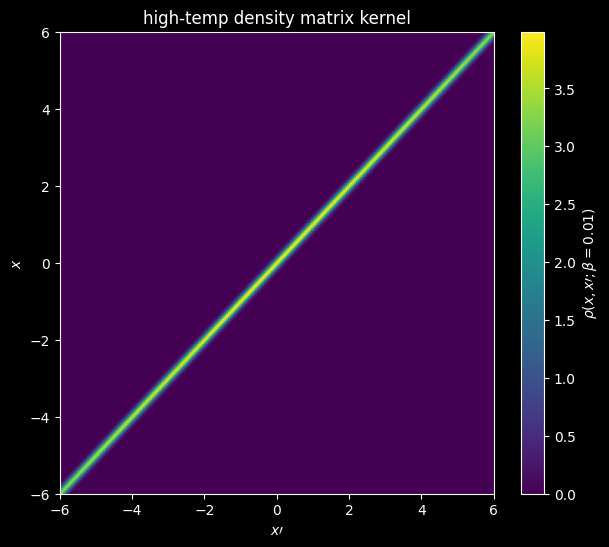

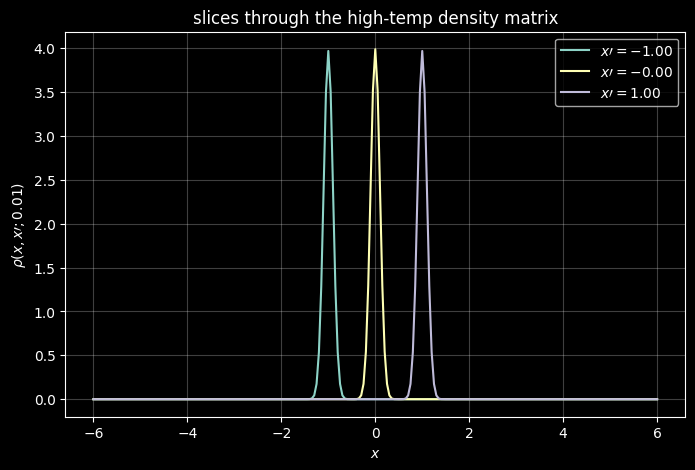

In [36]:
#plot act 2d density matrix shape
plt.figure(figsize=(7,6))
plt.imshow(P0, extent=[x.min(), x.max(), x.min(), x.max()], origin='lower', aspect='auto')
plt.colorbar(label=r'$\rho(x,x\prime;\beta=0.01)$')
plt.xlabel(r'$x\prime$')
plt.ylabel(r'$x$')
plt.title('high-temp density matrix kernel')
plt.show()

#plot a few slices through xprime to see the off-diagonal gaussian
plt.figure(figsize=(8,5))
for xp in [-1, 0, 1]:
    j = np.argmin(np.abs(x - xp))
    plt.plot(x, P0[:, j], label=fr"$x\prime={x[j]:.2f}$")
plt.xlabel(r'$x$')
plt.ylabel(r'$\rho(x,x\prime;0.01)$')
plt.title('slices through the high-temp density matrix')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

### Problem 3: grid spacing check

- kinetic gaussian has width sigma = sqrt(beta) = 0.1
- grid spacing dx = 0.05, so about 2 grid steps per sigma
- nearest off-diagonal should still be large

P[i,i+1]/P[i,i] ~ exp(-(dx**2)/(2*beta))


,quantity,value
0,sigma = sqrt(beta),0.100000
1,lambda_th = sqrt(2*pi*beta),0.250663
2,dx,0.050000
3,dx/sigma,0.500000
4,"predicted P_i,i+1 / P_i,i",0.882497
5,"numerical P_i,i+1 / P_i,i",0.882491


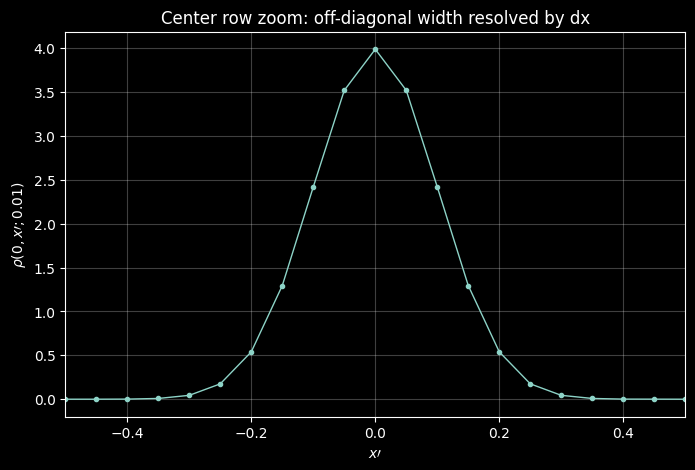

In [37]:
sigma = np.sqrt(beta0)
lambda_th = np.sqrt(2*np.pi*beta0)
ratio_pred = np.exp(-dx**2/(2*beta0))

center = N//2
ratio_num = P0[center, center+1] / P0[center, center]

spacing_table = pd.DataFrame({
    'quantity': ['sigma = sqrt(beta)', 'lambda_th = sqrt(2*pi*beta)', 'dx', 'dx/sigma', 'predicted P_i,i+1 / P_i,i', 'numerical P_i,i+1 / P_i,i'],
    'value': [sigma, lambda_th, dx, dx/sigma, ratio_pred, ratio_num]
})

display(spacing_table)

#show rq, center row zoom --> can see off diags to resolve
plt.figure(figsize=(8,5))
plt.plot(x, P0[center, :], marker='o', markersize=3, linewidth=1)
plt.xlim(-0.5, 0.5)
plt.xlabel(r'$x\prime$')
plt.ylabel(r'$\rho(0,x\prime;0.01)$')
plt.title('Center row zoom: off-diagonal width resolved by dx')
plt.grid(True, alpha=0.25)
plt.show()

### Problem 4: diagonal comparison, quantum vs classical at high T

- on the diagonal x=x', the high-temp becomes

roh(x,x;beta) ~ 1/sqrt(2*pi*beta) * exp(-beta*x**2/2)

- same shape as classical boltz. factor for v(x)=1/2x**2

roh_cl(x) ~ exp(-beta*V(x)) = exp(-beta*x**2/2)

- after normalizing the diagonal p. density,quantum and classical shapes should basically sit on top of each other at beta = 0.01


Z quantum grid approx = 45.31590544518885
Z classical high-T exact approx = 1/beta = 100.0


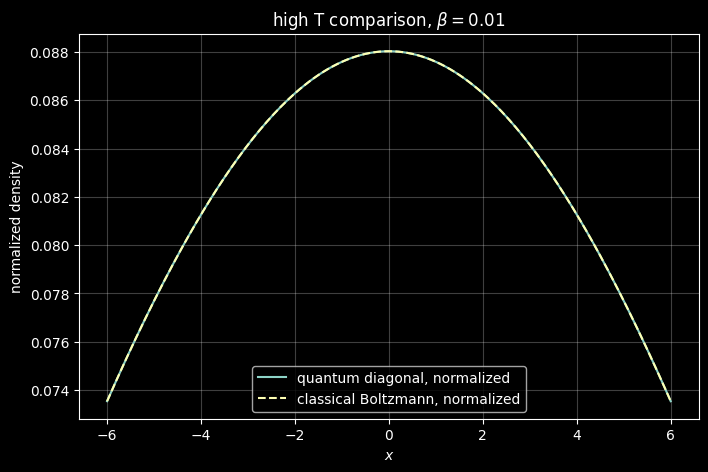

In [38]:
def normalize_density(y, dx):
    return y / (np.sum(y) * dx)

diag_high = np.diag(P0)
q_high = normalize_density(diag_high, dx)
cl_high = normalize_density(np.exp(-beta0*x**2/2), dx)

Z_high = np.trace(P0) * dx
Z_classical_exact = 1 / beta0

print('Z quantum grid approx =', Z_high)
print('Z classical high-T exact approx = 1/beta =', Z_classical_exact)

plt.figure(figsize=(8,5))
plt.plot(x, q_high, label='quantum diagonal, normalized')
plt.plot(x, cl_high, '--', label='classical Boltzmann, normalized')
plt.xlabel(r'$x$')
plt.ylabel('normalized density')
plt.title(r'high T comparison, $\beta=0.01$')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

###Problem 5:
#### high-temp limit (beta = 0.01)
- init. unormalized density op. roh = exp(-beta*H) & we found
- roh(x,x';beta) ~ 1/sqrt(2*pi*beta) * exp(-(x-x')**2/(2*beta) - (beta/4)*(x**2 + x'**2))
- at this temperature, diagonal roh(x,x) looks basically identical to classical exp(-beta*v(x))
#### matrix squaring to low temp

- reach beta = 5.12 --> property roh(2*beta) = roh(beta)^2
- numerically P_new = dx * (P_old @ P_old)
- repeat squaring 9 times starting from beta = 0.01

- tr(roh) decrease as beta increase, higher energy get suppressed
- at large beta, sum exp(-beta*En) dominated by exp(-beta*E0)

#### compare at beta = 5.12

- classically, exp(-2.56*x**2) becomes very sharp peak at x = 0
- quantum,roh diagonal -> |psi0(x)|^2 ~ exp(-x**2)/sqrt(pi)
- quantum distro. is broader
#### to get ground
- at large beta, E0 = - d/d beta ln(tr(roh))
- since units hbar = m = w = 1, E0 ~ 0.5
- numerical result at beta = 5.12 matches expected 1/2

In [39]:
def matrix_square(P, dx):
    return dx * (P @ P)

P = P0.copy()
betas = [beta0]
Zs = [np.trace(P) * dx]
Ps = [P.copy()]

for k in range(9):
    P = matrix_square(P, dx)
    betas.append(beta0 * 2**(k+1))
    Zs.append(np.trace(P) * dx)
    Ps.append(P.copy())

squaring_table = pd.DataFrame({'step': np.arange(len(betas)), 'beta': betas, 'Z = Tr(P) dx': Zs, 'ln Z': np.log(Zs)})
display(squaring_table)

,step,beta,Z = Tr(P) dx,ln Z
0,0,0.01,45.315905,3.813658
1,1,0.02,30.184471,3.407328
2,2,0.04,19.168451,2.953266
3,3,0.08,11.313129,2.425964
4,4,0.16,6.120778,1.811689
5,5,0.32,3.107973,1.133971
6,6,0.64,1.536142,0.429274
7,7,1.28,0.730363,-0.314213
8,8,2.56,0.301334,-1.199538
9,9,5.12,0.077770,-2.553995


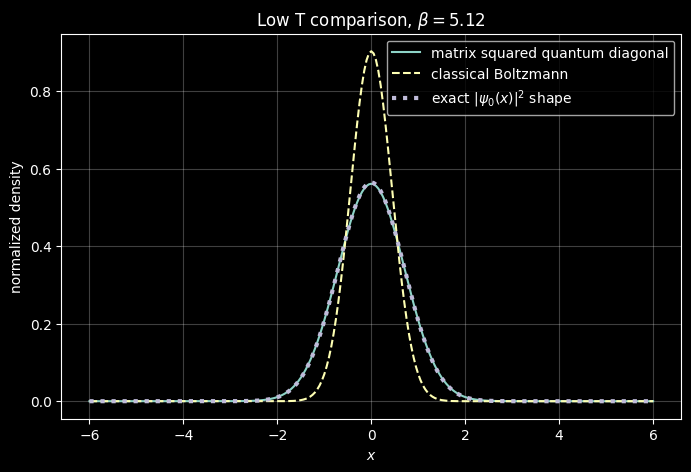

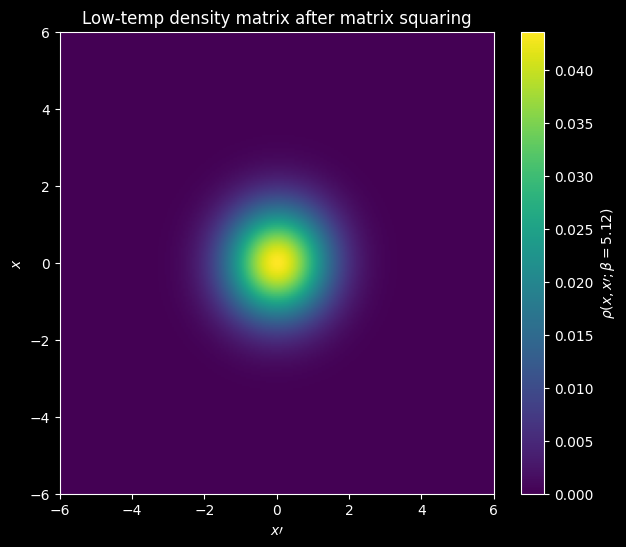

In [40]:
beta_low = betas[-1]
P_low = Ps[-1]

diag_low = np.diag(P_low)
q_low = normalize_density(diag_low, dx)
cl_low = normalize_density(np.exp(-beta_low*x**2/2), dx)
gs_exact = normalize_density(np.exp(-x**2), dx) # |psi_0|^2 up to norm

plt.figure(figsize=(8,5))
plt.plot(x, q_low, label='matrix squared quantum diagonal')
plt.plot(x, cl_low, '--', label='classical Boltzmann')
plt.plot(x, gs_exact, ':', linewidth=3, label=r'exact $|\psi_0(x)|^2$ shape')
plt.xlabel(r'$x$')
plt.ylabel('normalized density')
plt.title(fr'Low T comparison, $\beta={beta_low}$')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7,6))
plt.imshow(P_low, extent=[x.min(), x.max(), x.min(), x.max()], origin='lower', aspect='auto')
plt.colorbar(label=fr'$\rho(x,x\prime;\beta={beta_low})$')
plt.xlabel(r'$x\prime$')
plt.ylabel(r'$x$')
plt.title('Low-temp density matrix after matrix squaring')
plt.show()

quick note, qunatum low temp diag approach e**-x**2 not delta spike, classical is sharper as tries to fall into bottom of potent. but quntum ossilator keeps finite width


### problem 6: ground state energy from partition function slope
- at large beta Z(beta) = sum exp(-beta*En) ~ exp(-beta*E0)
- then E0 = - d/d beta ln(Z)
- estimate slope of ln(Z) vs beta using the largest beta points

fit_start = -4
E0 from slope = 0.6404887817427212

fit_start = -3
E0 from slope = 0.5755348687745416

fit_start = -2
E0 from slope = 0.5290850559933195

final E0 = 0.5290850559933195
exact QHO E0 = 0.5


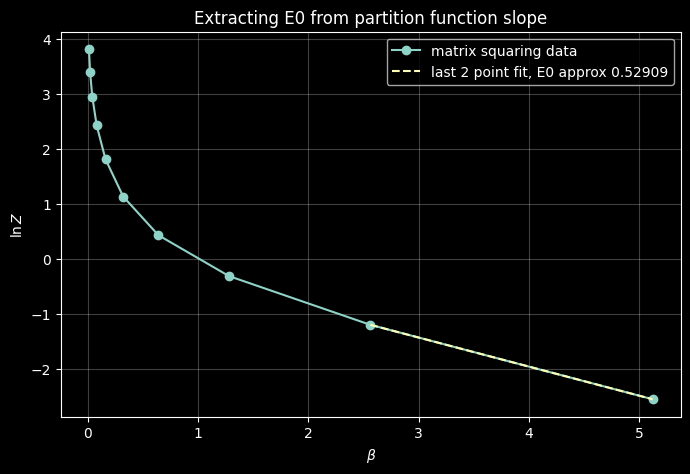

In [41]:
betas_arr = np.array(betas)
lnZ_arr = np.log(np.array(Zs))

for fit_start in [-4, -3, -2]:
    coeffs = np.polyfit(betas_arr[fit_start:], lnZ_arr[fit_start:], 1)
    slope, intercept = coeffs
    E0_from_slope = -slope

    print('fit_start =', fit_start)
    print('E0 from slope =', E0_from_slope)
    print()

fit_start = -2
coeffs = np.polyfit(betas_arr[fit_start:], lnZ_arr[fit_start:], 1)
slope, intercept = coeffs
E0_from_slope = -slope

fit_betas = betas_arr[fit_start:]
fit_lnZ = np.polyval(coeffs, fit_betas)

print('final E0 =', E0_from_slope)
print('exact QHO E0 = 0.5')

plt.figure(figsize=(8,5))
plt.plot(betas_arr, lnZ_arr, 'o-', label='matrix squaring data')
plt.plot(fit_betas, fit_lnZ, '--',
         label=fr'last 2 point fit, E0 approx {E0_from_slope:.5f}')

plt.xlabel(r'$\beta$')
plt.ylabel(r'$\ln Z$')
plt.title(r'Extracting E0 from partition function slope')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

### Direct diagonalization rationalization
- i would have done hamiltonian fininite diff
- eigenvalue problem
- take smallest evalue

E0 from direct diagonalization = 0.49992186278721784
exact E0 = 0.5
absolute error = 7.81372127821589e-05


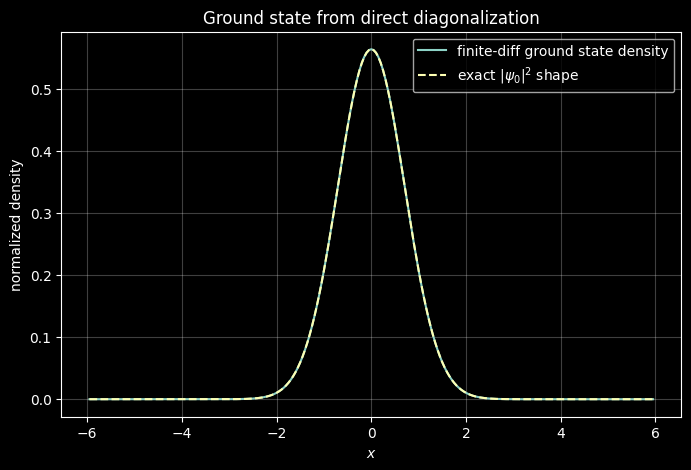

In [42]:
#finite difference Hamiltonian, endpoints in interior grid only
x_int = x[1:-1]
N_int = len(x_int)

main_diag_D2 = -2*np.ones(N_int) / dx**2
off_diag_D2 = np.ones(N_int-1) / dx**2

#ke = -1/2 D2
main_H = -0.5*main_diag_D2 + 0.5*x_int**2
off_H = -0.5*off_diag_D2

H = np.diag(main_H) + np.diag(off_H, 1) + np.diag(off_H, -1)
energies, vecs = np.linalg.eigh(H)

E0_diag = energies[0]
psi0_num = vecs[:, 0]
psi0_density = normalize_density(psi0_num**2, dx)
psi0_exact = normalize_density(np.exp(-x_int**2), dx)

print('E0 from direct diagonalization =', E0_diag)
print('exact E0 =', 0.5)
print('absolute error =', abs(E0_diag - 0.5))

plt.figure(figsize=(8,5))
plt.plot(x_int, psi0_density, label='finite-diff ground state density')
plt.plot(x_int, psi0_exact, '--', label=r'exact $|\psi_0|^2$ shape')
plt.xlabel(r'$x$')
plt.ylabel('normalized density')
plt.title('Ground state from direct diagonalization')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

### bottom line

- high-temp density matrix = narrow gaussian in (x-x') multiplied by slow boltzmann
- dx = 0.05 resolves off-diagonal gaussian since dx < sqrt(beta) = 0.1
- at beta = 0.01 --< normalized diagonal matches classical boltzmann shape
- after 9 iter. squaring steps (beta = 5.12), quantum diagonal is broad and groundstate-ish, classical sharp peak
- extracted ground state energy is close to exact QHO value E0 = 0.5
- (for both partition method & direct diag)